# Práctico 1 — Análisis y Visualización de Datos de Fútbol
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Cargar y explorar datos de eventos de fútbol (Wyscout)
- Construir visualizaciones estándar de análisis táctico: shot maps, heat maps, redes de pases
- Implementar Expected Goals (xG) como primera métrica avanzada
- Crear visualizaciones tipo radar para comparar jugadores
- Construir un dashboard básico interactivo
---

## 0. Instalación y setup del entorno

In [ ]:
# Instalación de librerías necesarias
# Ejecutar solo la primera vez
# !pip install mplsoccer matplotlib pandas numpy plotly scipy

In [31]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from mplsoccer import Pitch, VerticalPitch, FontManager
from mplsoccer.utils import FontManager

warnings.filterwarnings('ignore')

# Configuración de estilo global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Paleta de colores del proyecto
COLOR_FIELD   = '#1a472a'
COLOR_LINES   = '#ffffff'
COLOR_SHOT    = '#FFD700'
COLOR_GOAL    = '#FF4500'
COLOR_PASS    = '#00BFFF'

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


In [ ]:
import sys
import time
from pathlib import Path
from typing import List, Dict, Callable, Optional, Union

#import polars as pl
import pyarrow.parquet as pq  # Para inspeccionar metadatos de parquet

# -- CONFIGURACION DE RUTAS --
# Usamos los archivos parquet generados por P1_Carga_Optimizada.ipynb
DATASET_DIR = Path(r'C:\Users\usuario\Downloads\Dataset2026_parquet')

print(f'Dataset dir: {DATASET_DIR}')


Dataset dir: C:\Users\usuario\Downloads\Dataset2026_parquet
Archivos de eventos configurados: ['England', 'Spain', 'Italy', 'Germany', 'France', 'World_Cup', 'European_Championship']


## 1. Carga y exploración de datos

El dataset de contiene archivos PARQUET con los eventos:
- `events_*.parquet`: eventos por liga (el más importante para este práctico)

Y los archivos JSON con distintas entidades:
- `players.json`: metadata de jugadores
- `teams.json`: metadata de equipos
- `matches_*.json`: información de partidos

### 1.1 Lectura Optimizada de eventos desde Parquet

In [102]:
def load_events_parquet(
    parquet_path: Path, 
    columns: Optional[List[str]] = None, 
    filters: Optional[List[tuple]] = None
) -> pd.DataFrame:
    """
    Carga eventos desde un archivo Parquet de forma optimizada.
    
    Parametros
    ----------
    parquet_path : Path al archivo .parquet.
    columns : Subconjunto de columnas a leer (None = todas).
    filters : Lista de tuplas para filtrar antes de cargar.
              Ejemplo: [('eventName', '==', 'Shot')]
    """
    print(f'[INFO] Cargando {parquet_path.name}...')
    t0 = time.time()
    
    # Leer con pyarrow + pandas para mejor rendimiento y control de tipos
    df = pd.read_parquet(
        parquet_path, 
        columns=columns, 
        filters=filters, 
        engine='pyarrow'
    )
    
    elapsed = time.time() - t0
    print(f'[INFO] Cargado en {elapsed:.2f}s | Filas: {len(df):,} | Columnas: {len(df.columns)}')
    return df

df_events = load_events_parquet(
    DATASET_DIR / 'events_England.parquet',
    columns= ['eventId', 'subEventName', 'tags', 'playerId', 'positions', 'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec', 'subEventId', 'id']
)

[INFO] Cargando events_England.parquet...
[INFO] Cargado en 1.13s | Filas: 643,150 | Columnas: 12


In [103]:
df_events.head(3)

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],25413,"[{'x': 49, 'y': 49}, {'x': 31, 'y': 78}]",2499719,Pass,1609,1H,2.758649,85,177959171
1,8,High pass,[{'id': 1801}],370224,"[{'x': 31, 'y': 78}, {'x': 51, 'y': 75}]",2499719,Pass,1609,1H,4.946850,83,177959172
2,8,Head pass,[{'id': 1801}],3319,"[{'x': 51, 'y': 75}, {'x': 35, 'y': 71}]",2499719,Pass,1609,1H,6.542188,82,177959173


In [104]:
def load_json(path: str) -> pd.DataFrame:
    """Carga un archivo JSON de Wyscout y devuelve un DataFrame."""
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data)

In [105]:
# Carga de metadata de jugadores y equipos

players = load_json(os.path.join(DATASET_DIR, 'players.json'))
teams   = load_json(os.path.join(DATASET_DIR, 'teams.json'))

# Exploración inicial del schema de eventos
print('=== ESTRUCTURA DE UN EVENTO ===')
event_sample = df_events.iloc[0]
for col, val in event_sample.items():
    print(f'  {col}: {val}')

=== ESTRUCTURA DE UN EVENTO ===
  eventId: 8
  subEventName: Simple pass
  tags: [{'id': 1801}]
  playerId: 25413
  positions: [{'x': 49, 'y': 49} {'x': 31, 'y': 78}]
  matchId: 2499719
  eventName: Pass
  teamId: 1609
  matchPeriod: 1H
  eventSec: 2.7586489999999912
  subEventId: 85
  id: 177959171


In [ ]:
def parse_positions(pos_list):
    """Extrae coordenadas x,y del campo (0-100) desde el campo 'positions'."""
    if isinstance(pos_list, list) and len(pos_list) >= 1:
        return pos_list[0].get('x', np.nan), pos_list[0].get('y', np.nan)
    return np.nan, np.nan

def parse_end_positions(pos_list):
    """Extrae posición final de la acción."""
    if isinstance(pos_list, list) and len(pos_list) >= 2:
        return pos_list[1].get('x', np.nan), pos_list[1].get('y', np.nan)
    return np.nan, np.nan

def parse_tags(tag_list):
    """Extrae lista de IDs de tags."""
    if isinstance(tag_list.tolist(), list):
        return [t.get('id') for t in tag_list.tolist()]
    return []

# Aplicamos parseo vectorizado
df_events[['x', 'y']] = df_events['positions'].apply(
    lambda p: pd.Series(parse_positions(p.tolist()))
)
df_events[['end_x', 'end_y']] = df_events['positions'].apply(
    lambda p: pd.Series(parse_end_positions(p.tolist()))
)
df_events['tag_ids'] = df_events['tags'].apply(parse_tags)

# Mapeamos coordenadas Wyscout (0-100) al sistema mplsoccer (campo 105x68)
df_events['x_m']     = df_events['x']     / 100 * 105
df_events['y_m']     = df_events['y']     / 100 * 68
df_events['end_x_m'] = df_events['end_x'] / 100 * 105
df_events['end_y_m'] = df_events['end_y'] / 100 * 68

# IDs de tags relevantes (documentados en el paper de Wyscout)
TAG_GOAL       = 101
TAG_ON_TARGET  = 1801
TAG_ACCURATE   = 1801  # pase preciso

df_events['is_goal']      = df_events['tag_ids'].apply(lambda t: TAG_GOAL in t)
df_events['is_on_target'] = df_events['tag_ids'].apply(lambda t: TAG_ON_TARGET in t)

print(f'Eventos con coordenadas: {df_events.dropna(subset=["x","y"]).shape[0]:,}')
print(df_events[['eventId','subEventName','x_m','y_m','is_goal']].head())

### 1.2 Distribución de tipos de eventos

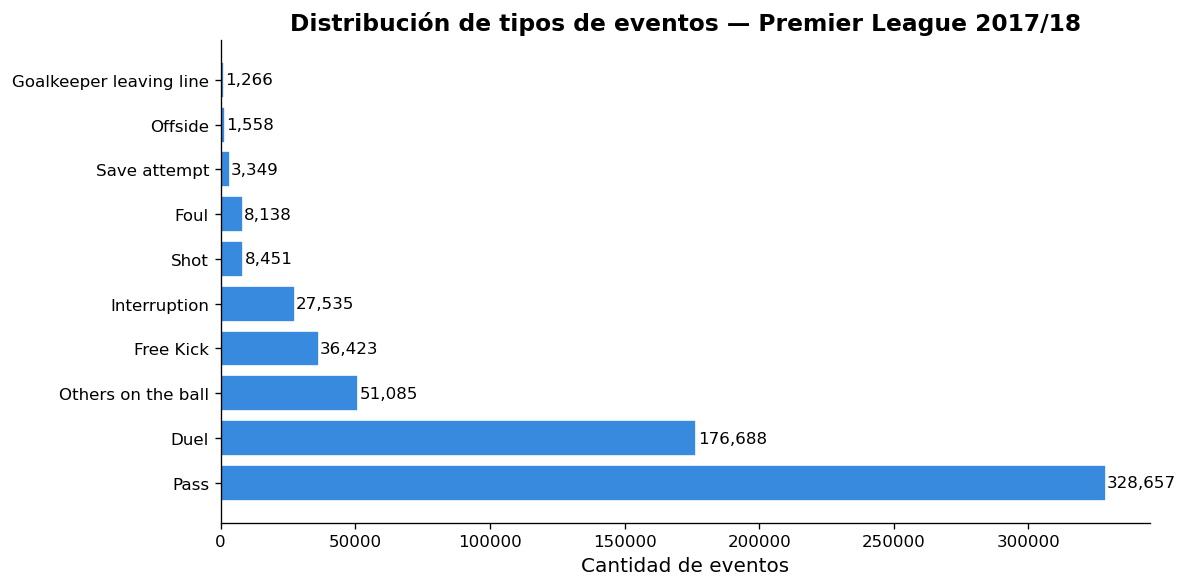

In [ ]:
# Distribución de eventos
event_counts = df_events['eventName'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(event_counts.index, event_counts.values, color='#378ADD', edgecolor='white')
ax.set_xlabel('Cantidad de eventos', fontsize=12)
ax.set_title('Distribución de tipos de eventos — Premier League 2017/18', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 500, bar.get_y() + bar.get_height()/2, f'{w:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Shot Maps — Mapa de tiros

El shot map es una de las visualizaciones más icónicas del análisis de fútbol.
Muestra la ubicación de cada tiro, diferenciando goles de tiros sin gol.

In [79]:
# Filtramos tiros al arco
df_shots = df_events[df_events['eventName'] == 'Shot'].copy()
print(f'Total de tiros: {len(df_shots):,}')
print(f'Goles: {df_shots["is_goal"].sum():,}')
print(f'Tasa de conversión: {df_shots["is_goal"].mean():.1%}')

Total de tiros: 8,451
Goles: 914
Tasa de conversión: 10.8%


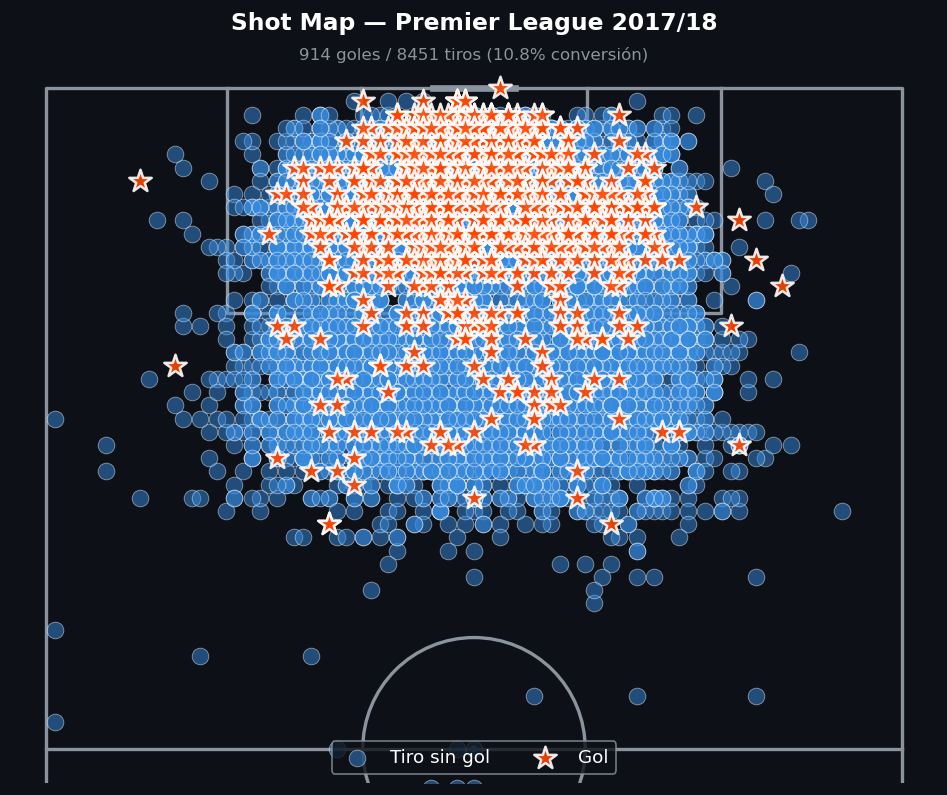

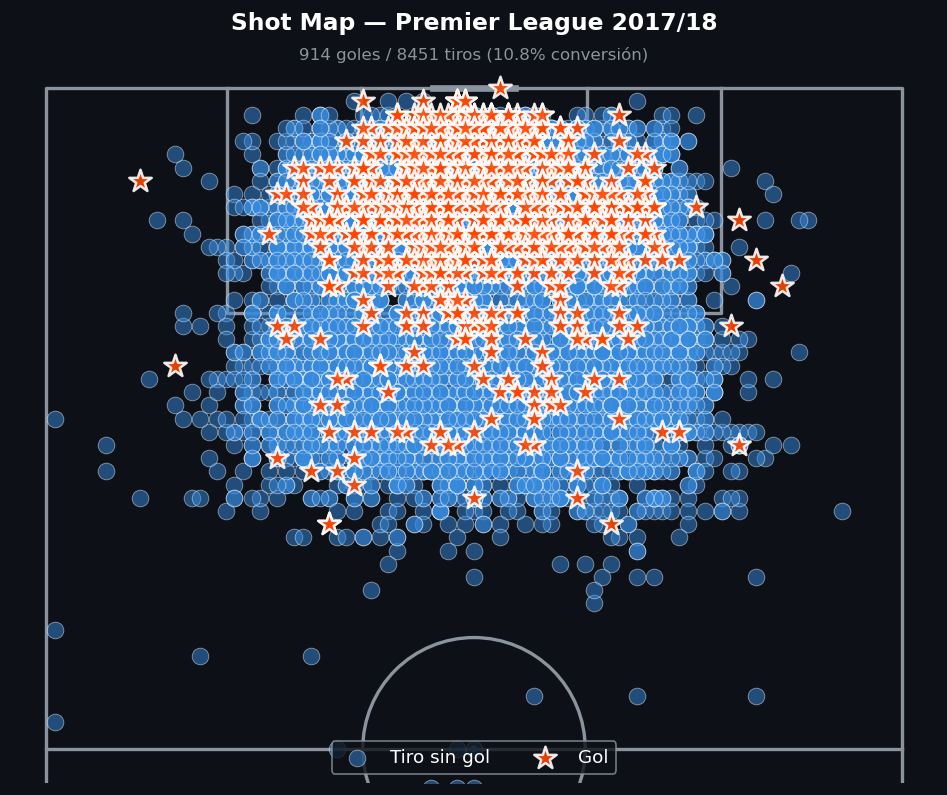

In [80]:
def plot_shot_map(df_shots, team_name=None, title=None):
    """
    Genera un shot map profesional con mplsoccer.
    
    Parámetros
    ----------
    df_shots  : DataFrame con columnas x_m, y_m, is_goal
    team_name : nombre del equipo (opcional, filtra)
    title     : título personalizado
    """
    data = df_shots.copy()
    if team_name:
        data = data[data['teamId'] == team_name]

    pitch = VerticalPitch(
        pitch_type='opta',
        pitch_color='#0d1117',
        line_color='#8b949e',
        half=True,
        line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(8, 8), constrained_layout=True)
    fig.set_facecolor('#0d1117')

    # Tiros que no son gol
    no_goal = data[~data['is_goal']]
    pitch.scatter(
        no_goal['x'], no_goal['y'],
        s=100, alpha=0.5, edgecolors='white',
        linewidth=0.5, c='#378ADD', ax=ax, zorder=3,
        label='Tiro sin gol'
    )

    # Goles
    goals = data[data['is_goal']]
    pitch.scatter(
        goals['x'], goals['y'],
        s=200, alpha=0.9, edgecolors='white',
        linewidth=1.5, c='#FF4500', marker='*', ax=ax, zorder=4,
        label='Gol'
    )

    ax.legend(
        loc='lower center', ncol=2, fontsize=11,
        facecolor='#0d1117', edgecolor='#8b949e', labelcolor='white'
    )
    _title = title or f'Shot Map — {team_name or "Liga completa"}'
    ax.set_title(_title, color='white', fontsize=14, fontweight='bold', pad=15)
    ax.text(
        50, 102,
        f'{len(goals)} goles / {len(data)} tiros ({len(goals)/max(len(data),1):.1%} conversión)',
        ha='center', va='bottom', color='#8b949e', fontsize=10
    )

    plt.show()
    return fig

# Visualizamos la liga completa
plot_shot_map(df_shots, title='Shot Map — Premier League 2017/18')

## 3. Heat Maps — Densidad de acciones

Los heat maps permiten ver dónde en el campo ocurren más acciones de un tipo determinado.

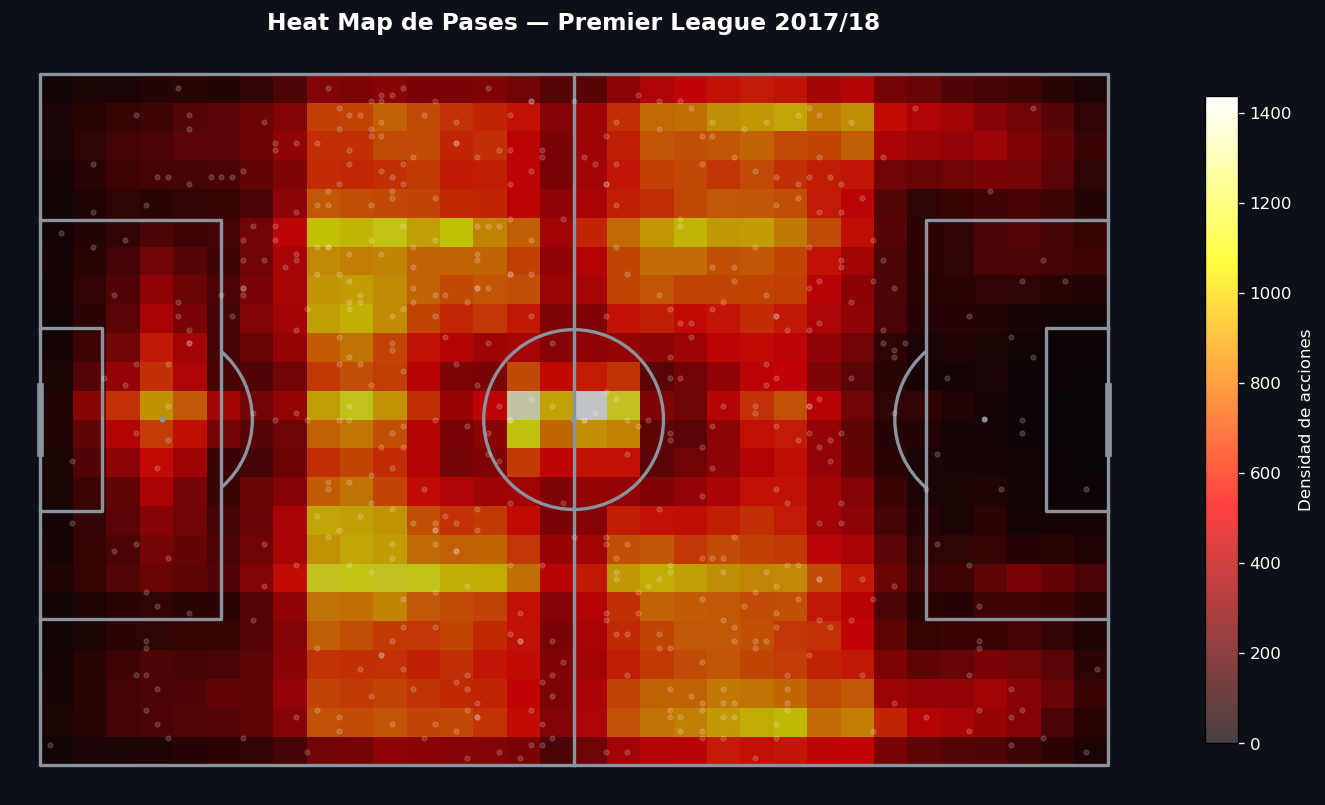

In [81]:
def plot_heatmap(df, event_type='Pass', team_id=None, cmap='hot', title=None):
    """
    Genera un heat map de densidad de eventos con KDE.
    """
    data = df[df['eventName'] == event_type].copy()
    if team_id:
        data = data[data['teamId'] == team_id]
    data = data.dropna(subset=['x', 'y'])

    pitch = Pitch(
        pitch_type='opta',
        pitch_color='#0d1117',
        line_color='#8b949e',
        line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(12, 8))
    fig.set_facecolor('#0d1117')

    # KDE a través de mplsoccer (gestiona bien el campo)
    bs = pitch.bin_statistic(
        data['x'], data['y'], statistic='count', bins=(32, 24)
    )
    heatmap = pitch.heatmap(bs, ax=ax, cmap=cmap, edgecolors='none', alpha=0.75)
    pitch.scatter(
        data['x'].sample(min(500, len(data))), 
        data['y'].sample(min(500, len(data))),
        s=8, alpha=0.15, color='white', ax=ax, zorder=5
    )

    cbar = fig.colorbar(heatmap, ax=ax, shrink=0.7)
    cbar.set_label('Densidad de acciones', color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    _title = title or f'Heat Map — {event_type}'
    ax.set_title(_title, color='white', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

plot_heatmap(df_events, event_type='Pass', title='Heat Map de Pases — Premier League 2017/18')

In [82]:
# Comparación de heat maps entre dos equipos
# Ajustá los IDs según el equipo de interés en tu dataset

# Primer paso: encontrar el ID del equipo
#print(teams[['wyId','name']].head(20))
# Pandas permite usar .str para acceder directamente a las claves de un diccionario
teams[teams['area'].str['name'] == 'England'][['wyId','name']]


,wyId,name
0,1613,Newcastle United
8,1673,Huddersfield Town
26,1659,AFC Bournemouth
27,1651,Brighton & Hove Albion
39,1646,Burnley
54,1631,Leicester City
55,1633,West Ham United
56,1639,Stoke City
60,1644,Watford
65,1623,Everton


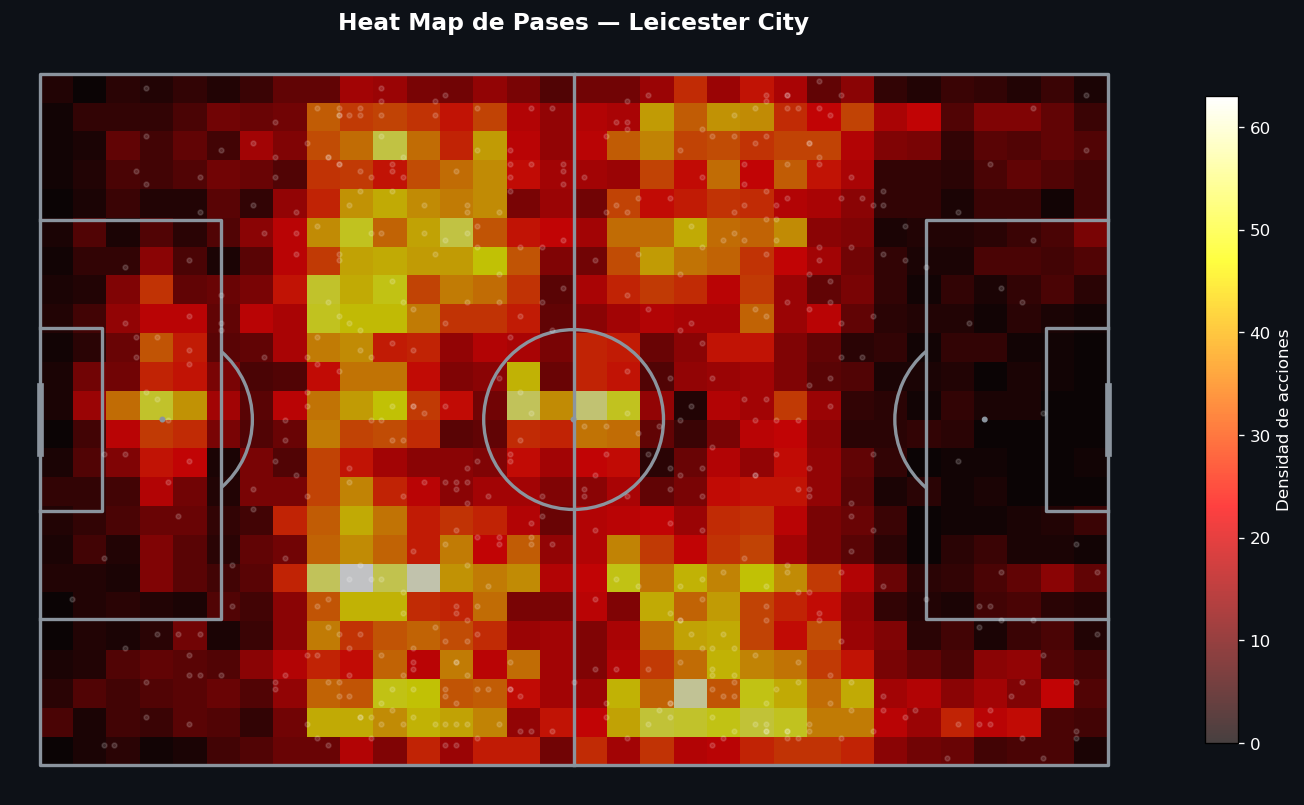

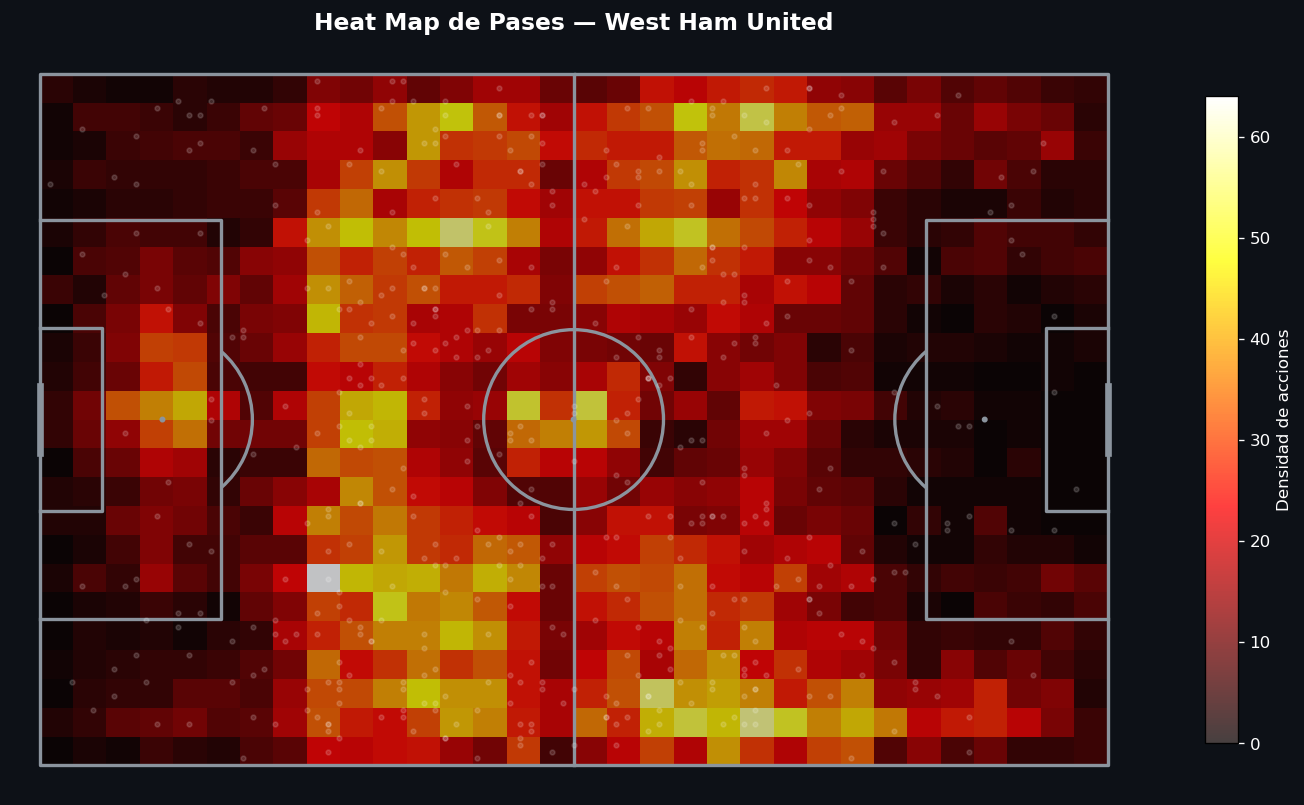

In [83]:
plot_heatmap(df_events, event_type='Pass', team_id=1631, title='Heat Map de Pases — Leicester City')
plot_heatmap(df_events, event_type='Pass', team_id=1633, title='Heat Map de Pases — West Ham United')

## 4. Expected Goals (xG)

xG es la métrica central del análisis moderno. Estima la probabilidad de que un tiro
se convierta en gol basándose en la posición y otras características.

Vamos a implementar un modelo xG simple usando regresión logística.

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, brier_score_loss
import matplotlib.patches as patches

def compute_shot_features(df_shots):
    """
    Computa features geométricas para el modelo xG.
    Referencia: Caley (2013), Lucey et al. (2014)
    """
    df = df_shots.copy()
    # Coordenadas en metros (campo 105x68)
    # En Wyscout, el arco atacante está en x=100
    df['dist_goal'] = np.sqrt(
        ((100 - df['x']) / 100 * 105) ** 2 +
        ((50 - df['y'])  / 100 * 68)  ** 2
    )
    # Ángulo al arco (radianes → grados)
    # Postes en y=44.2% y y=55.8% (ancho del arco 7.32m)
    post_left  = 44.2
    post_right = 55.8
    a = np.sqrt(((100 - df['x'])**2 + (post_left  - df['y'])**2))
    b = np.sqrt(((100 - df['x'])**2 + (post_right - df['y'])**2))
    c = post_right - post_left  # ancho del arco normalizado
    # Ley del coseno
    cos_angle = (a**2 + b**2 - c**2) / (2 * a * b + 1e-9)
    df['angle_goal'] = np.degrees(np.arccos(cos_angle.clip(-1, 1)))

    # Indicadores adicionales
    df['is_head'] = df['subEventName'].str.lower().str.contains('head', na=False).astype(int)
    df['is_direct_fk'] = df['subEventName'].str.lower().str.contains('free kick', na=False).astype(int)

    return df

df_shots_fe = compute_shot_features(df_shots.dropna(subset=['x','y']))

features = ['dist_goal', 'angle_goal', 'is_head', 'is_direct_fk']
X = df_shots_fe[features].fillna(0).values
y = df_shots_fe['is_goal'].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo de regresión logística (baseline xG)
model_xg = LogisticRegression(max_iter=1000, C=0.5)
auc_scores = cross_val_score(model_xg, X_scaled, y, cv=5, scoring='roc_auc')

model_xg.fit(X_scaled, y)
df_shots_fe['xG'] = model_xg.predict_proba(X_scaled)[:, 1]

print(f'AUC (5-fold CV): {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')
print(f'Brier Score: {brier_score_loss(y, df_shots_fe["xG"]):.4f}')
print(f'\nTotal xG en la liga: {df_shots_fe["xG"].sum():.1f}')
print(f'Goles reales: {y.sum()}')

AUC (5-fold CV): 0.7628 ± 0.0118
Brier Score: 0.0856

Total xG en la liga: 914.7
Goles reales: 914


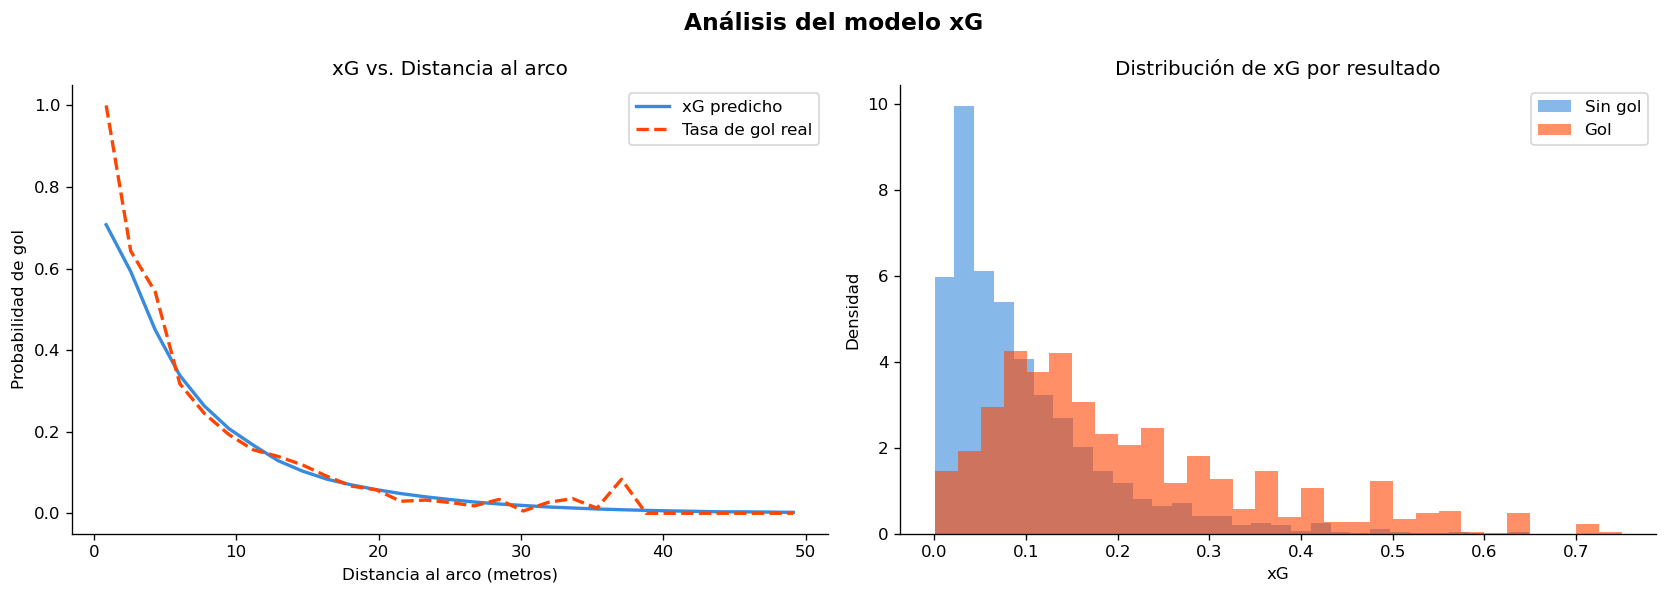

In [85]:
# Visualización: xG vs distancia al arco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis del modelo xG', fontsize=14, fontweight='bold')

# Panel izq: xG vs distancia
ax = axes[0]
# Curva promedio
dist_bins = np.linspace(0, 50, 30)
df_shots_fe['dist_bin'] = pd.cut(df_shots_fe['dist_goal'], bins=dist_bins)
avg_xg = df_shots_fe.groupby('dist_bin')['xG'].mean()
avg_goal = df_shots_fe.groupby('dist_bin')['is_goal'].mean()
bin_centers = [i.mid for i in avg_xg.index]

ax.plot(bin_centers, avg_xg.values, color='#378ADD', linewidth=2, label='xG predicho')
ax.plot(bin_centers, avg_goal.values, color='#FF4500', linewidth=2, linestyle='--', label='Tasa de gol real')
ax.set_xlabel('Distancia al arco (metros)')
ax.set_ylabel('Probabilidad de gol')
ax.set_title('xG vs. Distancia al arco')
ax.legend()
ax.spines[['top','right']].set_visible(False)

# Panel der: distribución de xG por categoría
ax2 = axes[1]
for is_goal, label, color in [(0, 'Sin gol', '#378ADD'), (1, 'Gol', '#FF4500')]:
    vals = df_shots_fe.loc[df_shots_fe['is_goal'] == is_goal, 'xG']
    ax2.hist(vals, bins=30, alpha=0.6, label=label, color=color, density=True)
ax2.set_xlabel('xG')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de xG por resultado')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Redes de Pases (Passing Networks)

Las redes de pases muestran cómo circula el balón entre los jugadores de un equipo.
Son una herramienta central para el análisis táctico moderno.

In [86]:
def build_passing_network(df_events, match_id, team_id):
    """
    Construye una red de pases para un partido y equipo específicos.
    Retorna nodos (posición media) y aristas (conexiones de pase).
    """
    mask = (
        (df_events['matchId'] == match_id) &
        (df_events['teamId'] == team_id) &
        (df_events['eventName'] == 'Pass')
    )
    df_match_passes = df_events[mask].copy()

    # Posición media de cada jugador (nodo)
    nodes = df_match_passes.groupby('playerId').agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('eventId', 'count')
    ).reset_index()

    # Conectamos pases consecutivos: el receptor del pase
    df_sorted = df_match_passes.sort_values(['matchId', 'matchPeriod', 'eventSec'])
    df_sorted['next_player'] = df_sorted['playerId'].shift(-1)
    df_sorted['next_team']   = df_sorted['teamId'].shift(-1)

    edges = df_sorted[
        df_sorted['next_team'] == team_id
    ].groupby(['playerId', 'next_player']).size().reset_index(name='count')

    # Solo aristas con al menos 3 pases
    edges = edges[edges['count'] >= 3]

    return nodes, edges


def plot_passing_network(nodes, edges, title='Red de Pases'):
    """
    Visualiza la red de pases sobre el campo.
    """
    pitch = Pitch(
        pitch_type='opta', pitch_color='#1a472a',
        line_color='#ffffff', line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(14, 9))
    fig.set_facecolor('#0d1117')

    # Aristas — grosor proporcional al número de pases
    max_count = edges['count'].max() if len(edges) > 0 else 1
    for _, edge in edges.iterrows():
        src = nodes[nodes['playerId'] == edge['playerId']]
        dst = nodes[nodes['playerId'] == edge['next_player']]
        if src.empty or dst.empty:
            continue
        alpha  = 0.3 + 0.6 * (edge['count'] / max_count)
        lw     = 1 + 4 * (edge['count'] / max_count)
        ax.plot(
            [src['x'].values[0], dst['x'].values[0]],
            [src['y'].values[0], dst['y'].values[0]],
            color='white', alpha=alpha, linewidth=lw, zorder=3
        )

    # Nodos — tamaño proporcional a pases realizados
    max_passes = nodes['passes_made'].max() if len(nodes) > 0 else 1
    scatter_size = 200 + 800 * (nodes['passes_made'] / max_passes)
    sc = pitch.scatter(
        nodes['x'], nodes['y'],
        s=scatter_size,
        c=nodes['passes_made'],
        cmap='YlOrRd',
        edgecolors='white', linewidth=1.5,
        ax=ax, zorder=5
    )
    plt.colorbar(sc, ax=ax, label='Pases realizados', shrink=0.6)

    ax.set_title(title, color='white', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()


# Ejemplo de uso — ajustá match_id y team_id
matches_path = os.path.join(DATA_DIR, 'matches_England.json')
df_matches = load_json(matches_path)
print('Primeros partidos disponibles:')
print(df_matches[['wyId','label']].head(5))

Primeros partidos disponibles:
      wyId                                         label
0  2500089              Burnley - AFC Bournemouth, 1 - 2
1  2500090  Crystal Palace - West Bromwich Albion, 2 - 0
2  2500091            Huddersfield Town - Arsenal, 0 - 1
3  2500092     Liverpool - Brighton & Hove Albion, 4 - 0
4  2500093            Manchester United - Watford, 1 - 0


Nodos: 14, Aristas (≥3 pases): 61


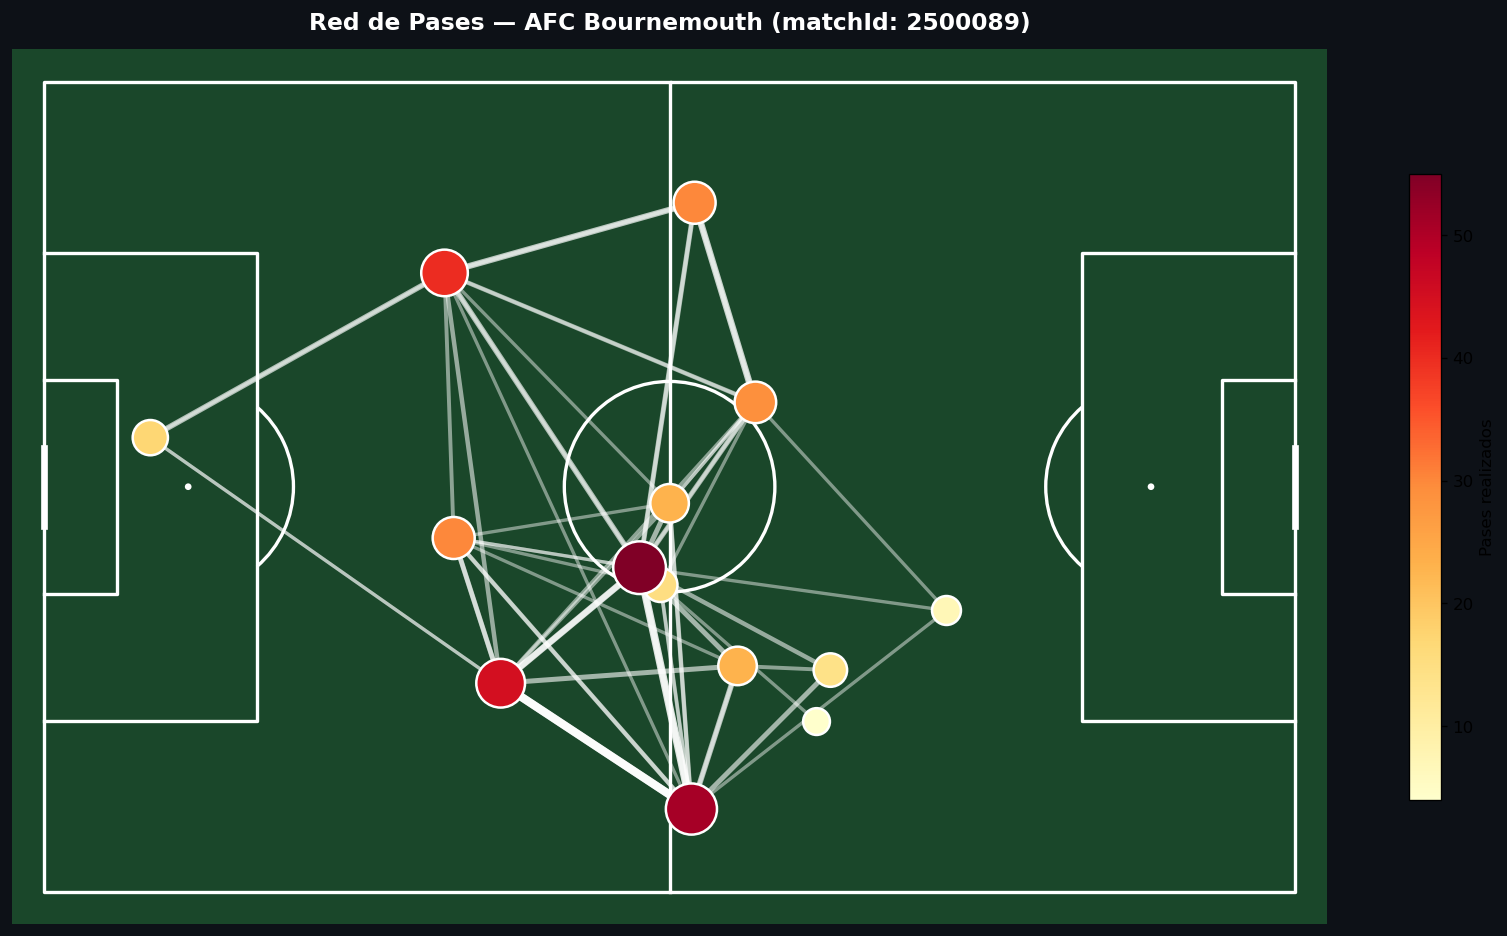

In [87]:
# Seleccionamos el primer partido disponible
first_match_id = df_matches['wyId'].iloc[0]

# Encontramos los dos equipos del partido
teams_in_match = df_events[
    df_events['matchId'] == first_match_id
]['teamId'].unique()

if len(teams_in_match) >= 1:
    team_id = teams_in_match[0]
    team_name = teams[teams['wyId'] == team_id]['name'].values
    team_name = team_name[0] if len(team_name) else str(team_id)

    nodes, edges = build_passing_network(df_events, first_match_id, team_id)
    print(f'Nodos: {len(nodes)}, Aristas (≥3 pases): {len(edges)}')
    plot_passing_network(
        nodes, edges,
        title=f'Red de Pases — {team_name} (matchId: {first_match_id})'
    )

## 6. Radar Charts — Comparación de jugadores

Los radares son la forma más usada para comparar perfiles de jugadores.
Vamos a crear radares con normalización por percentil respecto a la liga.

In [88]:
from mplsoccer import Radar

def build_player_stats(df_events, players_df, min_minutes=500):
    """
    Agrega estadísticas por jugador para construir perfiles.
    Retorna estadísticas normalizadas por 90 minutos.
    """
    # Pasadores y tiros
    passes = df_events[df_events['eventName'] == 'Pass'].groupby('playerId').agg(
        total_passes=('eventId', 'count'),
    ).reset_index()
    
    shots = df_events[df_events['eventName'] == 'Shot'].groupby('playerId').agg(
        total_shots=('eventId', 'count'),
        total_goals=('is_goal', 'sum'),
        total_xg=('xG', 'sum') if 'xG' in df_events.columns else ('is_goal', 'count')
    ).reset_index()

    duels = df_events[df_events['eventName'] == 'Duel'].groupby('playerId').agg(
        total_duels=('eventId', 'count')
    ).reset_index()

    carries = df_events[df_events['eventName'] == 'Free Kick'].groupby('playerId').agg(
        free_kicks=('eventId', 'count')
    ).reset_index()

    # Join
    stats = passes
    for df_merge in [shots, duels, carries]:
        stats = stats.merge(df_merge, on='playerId', how='outer')
    stats = stats.fillna(0)

    return stats

player_stats = build_player_stats(df_events, players)
print(f'Jugadores con estadísticas: {len(player_stats)}')
player_stats.head()

Jugadores con estadísticas: 515


,playerId,total_passes,total_shots,total_goals,total_xg,total_duels,free_kicks
0,0,6.0,1.0,0.0,1.0,18115.0,2277.0
1,36,898.0,10.0,0.0,10.0,182.0,28.0
2,38,224.0,3.0,0.0,3.0,73.0,39.0
3,48,2370.0,23.0,0.0,23.0,602.0,68.0
4,54,2196.0,80.0,10.0,80.0,601.0,251.0


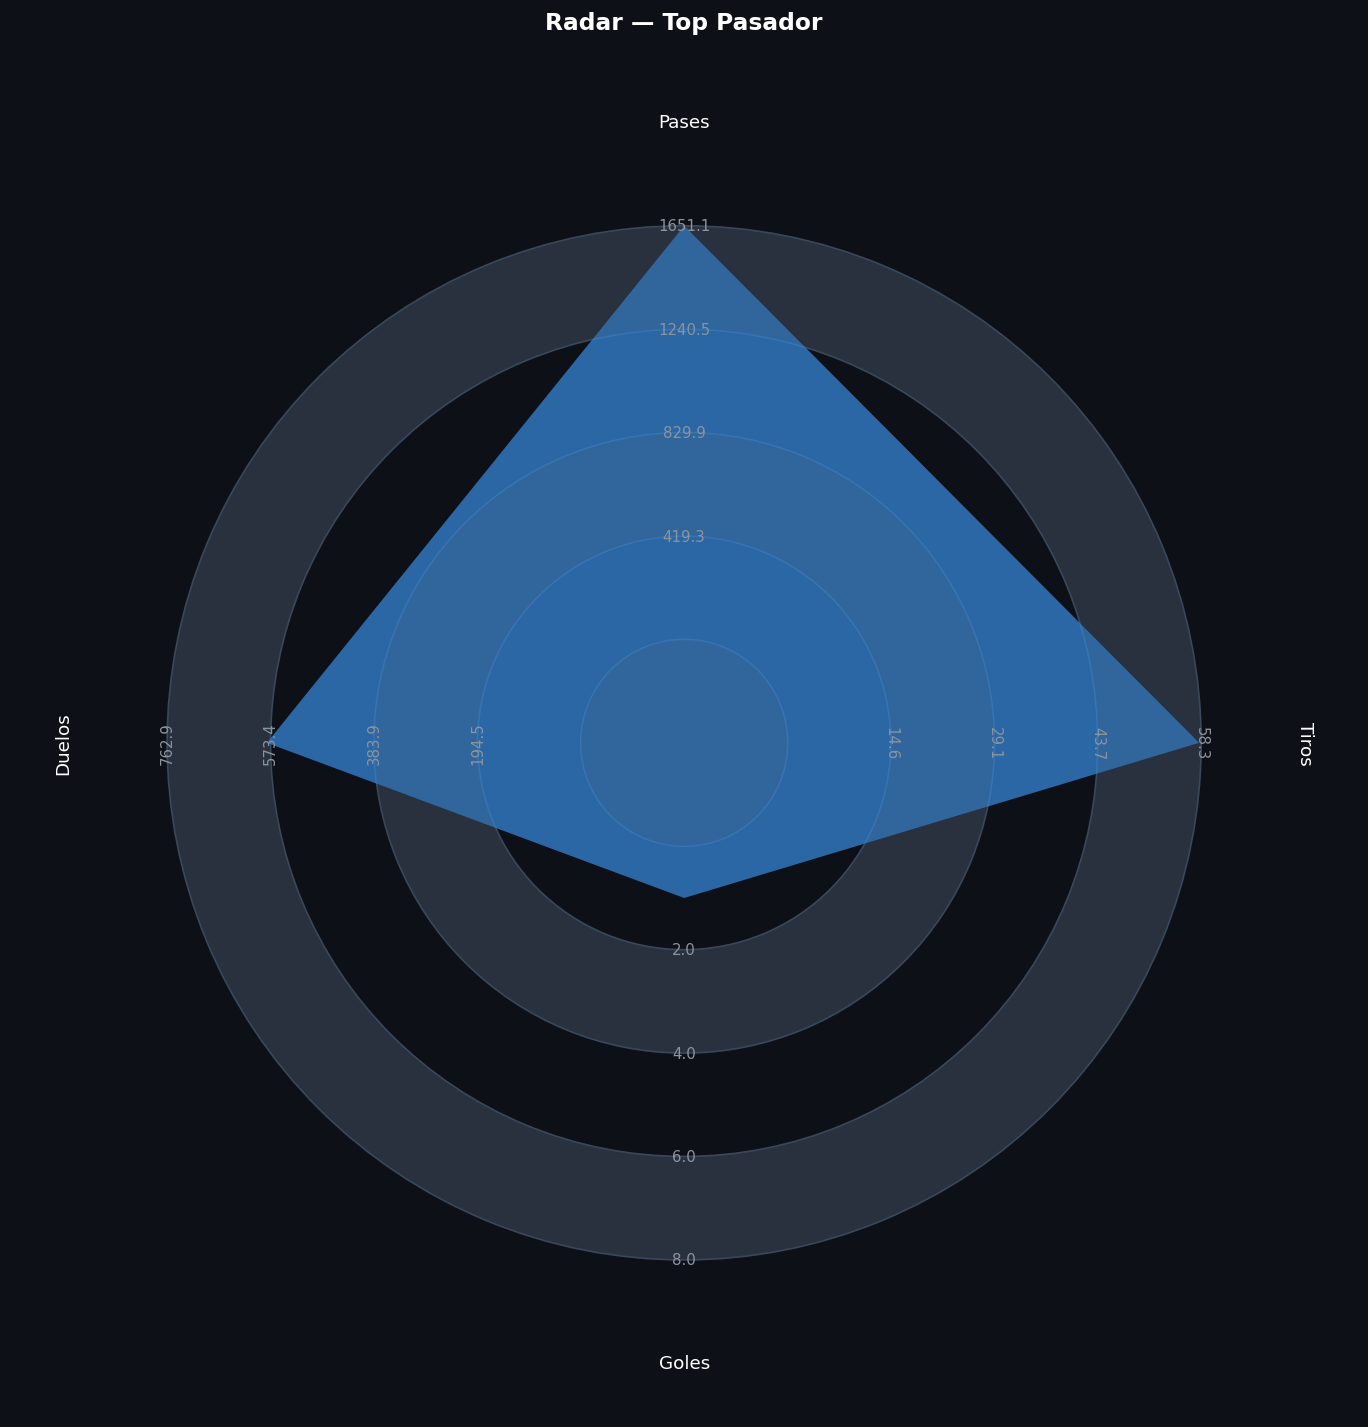

In [89]:
def plot_player_radar(player_stats_row, all_stats, player_name='Jugador'):
    """
    Genera un radar chart normalizado por percentil.
    """
    params    = ['total_passes', 'total_shots', 'total_goals', 'total_duels']
    labels    = ['Pases', 'Tiros', 'Goles', 'Duelos']
    low_vals  = [all_stats[p].quantile(0.05) for p in params]
    high_vals = [all_stats[p].quantile(0.95) for p in params]
    values    = [float(player_stats_row[p]) for p in params]

    radar = Radar(
        params=labels,
        min_range=low_vals,
        max_range=high_vals,
        num_rings=4,
        ring_width=1,
        center_circle_radius=1
    )
    fig, axs = radar.setup_axis()
    rings_inner = radar.draw_circles(ax=axs, facecolor='#28313D', edgecolor='#39485a')
    radar_output = radar.draw_radar(
        values, ax=axs,
        kwargs_radar={'facecolor': '#378ADD', 'alpha': 0.6},
        kwargs_rings={'facecolor': '#378ADD', 'alpha': 0.3}
    )
    range_labels = radar.draw_range_labels(ax=axs, fontsize=9, color='#8b949e')
    param_labels = radar.draw_param_labels(ax=axs, fontsize=11, color='white')

    fig.patch.set_facecolor('#0d1117')
    axs.set_facecolor('#0d1117')
    axs.set_title(f'Radar — {player_name}', color='white', fontsize=14, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

# Ejemplo: jugador con más pases en la liga
top_passer = player_stats.sort_values('total_passes', ascending=False).iloc[0]
plot_player_radar(top_passer, player_stats, player_name='Top Pasador')

## 7. Progressive Passes — Pases Progresivos

Un pase progresivo es aquel que avanza el balón significativamente hacia el arco rival.
La definición estándar (Wyscout/StatsBomb): pases que reducen la distancia al arco en al menos un 25%.

In [90]:
def is_progressive_pass(row, threshold=0.25):
    """
    Determina si un pase es progresivo.
    Definición: reduce la distancia al arco rival en ≥25%.
    """
    if pd.isna(row['x']) or pd.isna(row['end_x']):
        return False
    # Distancia al arco rival (x=100 en Wyscout)
    dist_start = np.sqrt((100 - row['x'])**2 + (50 - row['y'])**2)
    dist_end   = np.sqrt((100 - row['end_x'])**2 + (50 - row['end_y'])**2)
    # En campo rival + reducción significativa
    return (dist_end < dist_start * (1 - threshold)) and (row['x'] > 30)

df_passes = df_events[
    (df_events['eventName'] == 'Pass') & 
    df_events['end_x'].notna()
].copy()

df_passes['is_progressive'] = df_passes.apply(is_progressive_pass, axis=1)

prog_rate = df_passes['is_progressive'].mean()
print(f'Pases totales: {len(df_passes):,}')
print(f'Pases progresivos: {df_passes["is_progressive"].sum():,} ({prog_rate:.1%})')

# Top jugadores por pases progresivos
prog_by_player = df_passes.groupby('playerId').agg(
    total_passes=('eventId', 'count'),
    progressive_passes=('is_progressive', 'sum')
).reset_index()
prog_by_player['prog_rate'] = prog_by_player['progressive_passes'] / prog_by_player['total_passes']
prog_by_player = prog_by_player[prog_by_player['total_passes'] >= 200]
print('\nTop 10 jugadores por pases progresivos absolutos:')
print(prog_by_player.sort_values('progressive_passes', ascending=False).head(10).to_string())

Pases totales: 328,657
Pases progresivos: 51,125 (15.6%)

Top 10 jugadores por pases progresivos absolutos:
     playerId  total_passes  progressive_passes  prog_rate
325     38021          2672                 552   0.206587
33       3350          2024                 521   0.257411
293     25553          2713                 508   0.187247
4          54          2196                 424   0.193078
334     49876          2974                 410   0.137861
36       3361          1418                 408   0.287729
361     70389          1378                 376   0.272859
406    167145          1877                 371   0.197656
200      8945          1311                 371   0.282990
102      8013          1107                 357   0.322493


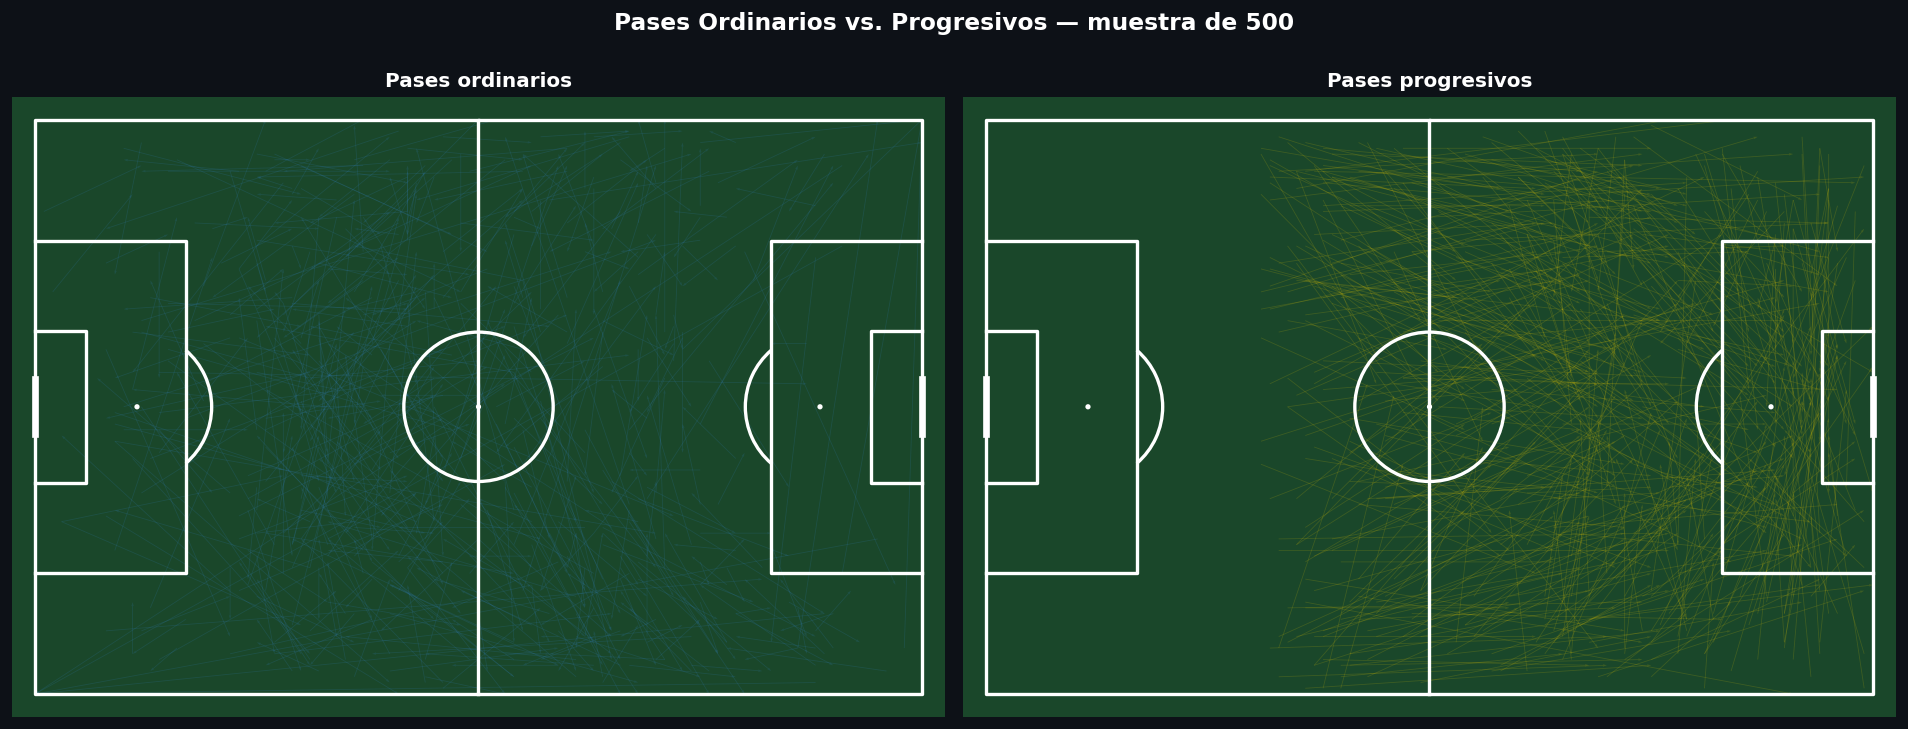

In [91]:
# Visualización de pases progresivos vs ordinarios
pitch = Pitch(pitch_type='opta', pitch_color='#1a472a', line_color='white', line_zorder=2)
fig, axes = pitch.draw(ncols=2, figsize=(16, 6))
fig.set_facecolor('#0d1117')

for ax, (label, mask) in zip(axes, [
    ('Pases ordinarios', ~df_passes['is_progressive']),
    ('Pases progresivos', df_passes['is_progressive'])
]):
    sample = df_passes[mask].dropna(subset=['x','y','end_x','end_y']).sample(min(500, mask.sum()))
    pitch.arrows(
        sample['x'], sample['y'],
        sample['end_x'], sample['end_y'],
        ax=ax, width=0.5, alpha=0.15,
        color='#378ADD' if 'ordinarios' in label else '#FFD700'
    )
    ax.set_title(label, color='white', fontsize=12, fontweight='bold')

plt.suptitle('Pases Ordinarios vs. Progresivos — muestra de 500', 
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Actividades propuestas

### Ejercicio 1 — Shot Map por equipo
Elegí dos equipos de la liga (por ejemplo Manchester City y Manchester United) y comparalos
en un shot map side-by-side. ¿Qué diferencias ves en el patrón de tiros?

### Ejercicio 2 — xG semanal
Calcula el xG acumulado por jornada para los 5 principales equipos de la liga.
Graficá la evolución temporal y compará con los goles reales marcados.

¿Qué equipos están sobre-rindiendo o sub-rindiendo respecto a su xG?

### Ejercicio 3 — Red de pases más conectada
Identifica el par de jugadores con mayor número de pases entre ellos en toda la temporada.
¿Corresponde a alguna combinación táctica conocida?

### Ejercicio 4 — Radar comparativo
Elegí 3 centrocampistas del dataset y comparalos en un radar con las siguientes métricas:
pases por 90 min, pases progresivos por 90 min, duelos ganados por 90 min, xG por 90 min.

### Ejercicio 5 — Análisis de pressing
El pressing puede medirse como la densidad de recuperaciones de balón en campo rival.
Construí un heat map de recuperaciones (ball recoveries) para identificar qué equipos
presionan más alto. Usá el tag de 'Ball lost' en el campo rival.

---
**Criterios de evaluación**: calidad visual, correctitud del análisis, insights relevantes y comentarios en el código.